### Looping Graph
Objectives:
1) Implement looping logic to route the flow of data back to the nodes;(实现循环逻辑，将数据路由回节点)
2) Create a single conditional edge to handle secision-making and control graph flow （创建一条条件边，用于处理分支决策和控制图流） 
Main Goal :Coding up Looping Logic（编写循环逻辑）
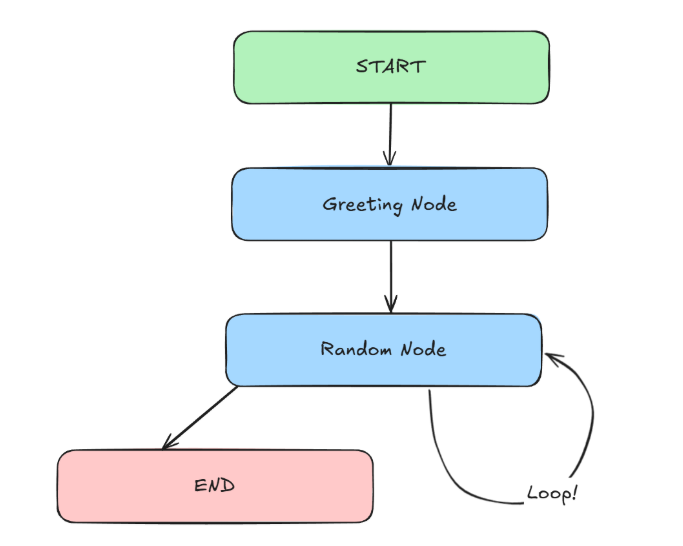

In [15]:
from typing import TypedDict,List
from langgraph.graph import StateGraph,END
import random

# 代码解析
#1） 类型化字典、列表
#2） 核心引擎——导入Langgraph的状态图构建器StateGraph（复杂维护画的图纸的拓扑结构）、和结束标志END；
#3）  random python 自带的标准库——产生0-10的数字；

In [8]:
class AgentState(TypedDict):
    name:str
    number:List[int]
    counter:int


In [ ]:
def greeting_node(state:AgentState) -> AgentState:
    """this node is greeting node which says hi to the person """
    state['name'] = f"Hi,there,{state['name']}"
    state['counter'] = 0

    return state

def random_node(state:AgentState) ->AgentState:
    """this node generates a random number form 0 to 10"""
    state['number'].append(random.randint(0,10))
    state['counter'] += 1

    return state

def should_continue(state:AgentState) -> str:
    """Functiom to decide what to do next"""
    if state['counter'] <5 :
        print("ENTEEING LOOP",state['counter'])
        return"loop"
    else:
        return"exit"
# 代码解析：
#1） random_node—— .append() : 意思是在这个列表末尾 原地写一个新的随机数；
#2） 为什么这里的列表可以原地修改：在python的底层世界中：数据分为两种：可变与不可变 Immutable
#3） 不可变对象如：字符串： str 数字int   例如之前的 = 重新赋值的操作；
#4） 可变对象——列表List 字典Dict 加东西子需要 .append 就好了；
#5） 注：+= 符合复制运算符：就是：state['counter'] = state['counter'] + 1

In [16]:
graph = StateGraph(AgentState)

graph.add_node("greeting",greeting_node)
graph.add_node("random",random_node)
graph.add_edge("greeting","random")

graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop":"random",
        "exit":END
    }
)

graph.set_entry_point("greeting")

app = graph.compile()

# 代码解析：
# 1） 误区纠正：在上一节课程中，我们学习了router 以及conditional edges 的具体使用 来执行数据分流的操作；
# 2） 但是不要形成思维定势——条件边必须挂在一个专门为了分流而建立的 不干活的 节点上；
# 3） 在Langgraph 的底层逻辑中，conditional edges 的定义是：
# 4） 派一个交警，站在莫格特定的车间出口出处、等这个车间干完活 ，立刻执行数据分流；
# 5） 因此一个 具体的条件边的创建流程应该是：
# graph.add_conditional_edges(
#      "从那个车间出来"，
#       “交警函数”，
#       {导航手册}
#）
#  总结：设定一个分支决策——是依赖谁的劳动成果；如果依赖NodeA 的加工数据——就直接把交警挂在这个NodeA上
# 如果是系统刚启动 亦或是多个节点汇聚需要统一到一个节点上；

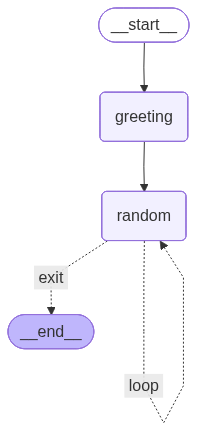

In [11]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [12]:
app.invoke({"name":"Vaibhav", "number":[], "counter":-100})

ENTEEING LOOP 1
ENTEEING LOOP 2
ENTEEING LOOP 3
ENTEEING LOOP 4


{'name': 'Hi,there,Vaibhav', 'number': [7, 4, 6, 2, 10], 'counter': 5}